In [13]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import scipy as sp 

import pyFDN

pio.renderers.default = "sphinx_gallery"

In [14]:
np.random.seed(5)

num_delays = 4
delays = np.random.randint(300, 1001, num_delays)
print(f"Delays: {delays}")
# unit vectors of the t-design for SH order 1

num_stages = 3
sparsity = 3

feedback_matrices = {}
feedback_matrices['velvet'] = pyFDN.construct_velvet_feedback_matrix(
    num_delays, num_stages, sparsity
)[0]
feedback_matrices['orthogonal'] = pyFDN.fdn_matrix_gallery(num_delays, 'orthogonal')


Delays: [506 418 700 373]


In [15]:
def jeremy_matrix(t_design_vecs, sigma):
    theta_t = np.empty((num_delays, num_delays))

    for i in range(num_delays):
        for j in range(num_delays):
            theta_t[i, j] = np.arccos(np.dot(t_design_vecs[i], t_design_vecs[j]))

    # build the Gaussian kernel matrix
    W = np.exp(-theta_t**2 / (2 * sigma**2))

    # build the skew symmetric matrix
    K = np.zeros((num_delays, num_delays))
    for i in range(num_delays):
        for j in range(num_delays):
            if i < j:
                K[i, j] = W[i, j]
                K[j, i] = -W[i, j] 

    tau = 2
    U = sp.linalg.expm( tau * K)
    return U

[[ 1.00000000e+00 -5.55111512e-17 -3.71288259e-17  0.00000000e+00]
 [-5.55111512e-17  1.00000000e+00  5.55111512e-17  8.15752340e-18]
 [-3.71288259e-17  5.55111512e-17  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  8.15752340e-18  0.00000000e+00  1.00000000e+00]]


/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_88810/345246092.py:6: RuntimeWarning: invalid value encountered in arccos
  theta_t[i, j] = np.arccos(np.dot(t_design_vecs[i], t_design_vecs[j]))


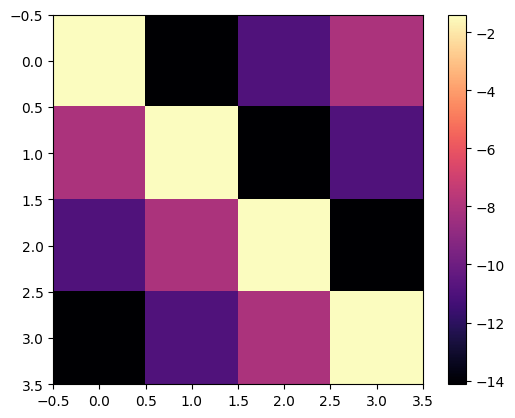

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_88810/345246092.py:9: RuntimeWarning: divide by zero encountered in divide
  W = np.exp(-theta_t**2 / (2 * sigma**2))


In [16]:
# construct Jeremy's feedback matrix
t_design_vecs = [
    [0.5774, 0.5774, 0.5774],
    [0.5774, -0.5774, -0.5774],
    [-0.5774, 0.5774, -0.5774],
    [-0.5774, -0.5774, 0.5774]
]

sigma = 1


U = jeremy_matrix(t_design_vecs, sigma)
print(U @ U.transpose())  # should be identity

# plot the matrix using imshow 
plt.imshow(20*np.log10(np.abs(U)), cmap='magma')
plt.colorbar()
plt.show()

for tau in [0, 0.075, 0.1, 0.2, 0.3, 0.9]:
    name = f'jeremy_tau_{tau}'
    feedback_matrices[name] = jeremy_matrix(t_design_vecs, tau)

In [17]:
# for name, feedback_matrix in feedback_matrices.items():
#     P = pyFDN.loop_tf(delays, feedback_matrix)
#     adj_mat = pyFDN.adj_poly(P, "z^1")
#     print(f"Feedback matrix: {name}, shape: {feedback_matrix.shape}, number of taps: {P.shape[2]}")
#     pyFDN.plot_impulse_response_matrix(
#         None,
#         P.transpose(2, 0, 1),
#         xlabel="Time (samples)",
#         ylabel="Sample value",
#         title="Characteristic matrix",
#         linewidth=0.6,
#     )
#     plt.show()

#     pyFDN.plot_impulse_response_matrix(
#         None,
#         adj_mat.transpose(2, 0, 1),
#         xlabel="Time (samples)",
#         ylabel="Sample value",
#         title="Adjugate of the characteristic matrix",
#         linewidth=0.6,
#     )
#     plt.show()



In [18]:
coord_labels = [
    f"{_k % num_delays + 1}{_k // num_delays + 1}" for _k in range(num_delays**2)
]

for name, feedback_matrix in feedback_matrices.items():
    P = pyFDN.loop_tf(delays, feedback_matrix)
    adj_mat = pyFDN.adj_poly(P, "z^1")

    max_correlation = pyFDN.max_corr(adj_mat)

    # statistics over the upper triangle (each pair counted once)
    _upper = max_correlation[np.triu_indices(max_correlation.shape[0], k=1)]
    _upper = np.abs(_upper)
    corr_values = _upper[_upper >= np.finfo(float).eps]

    median_corr = np.median(corr_values)
    iqr_corr = np.percentile(corr_values, 75) - np.percentile(corr_values, 25)

    print(f"Feedback matrix: {name}")
    print(f"Loop transfer function P: {P.shape}")
    print(f"Adjugate matrix: {adj_mat.shape}")
    print(f"Median correlation metric: {median_corr:.4f}")
    print(f"Interquartile range:       {iqr_corr:.4f}")


    fig_heat = go.Figure(
        go.Heatmap(
            z=np.abs(max_correlation),
            x=coord_labels,
            y=coord_labels,
            zmin=0,
            zmax=1,
            colorscale="gray",
            colorbar={"title": "|max corr|"},
        )
    )
    fig_heat.update_layout(
        title="Inter-channel maximum correlation",
        xaxis={"title": "ij", "type": "category"},
        yaxis={"title": "kl", "type": "category", "autorange": "reversed"},
        template="plotly_white",
        height=600,
        width=700,
    )
    fig_heat.show()

Feedback matrix: velvet
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.1414
Interquartile range:       0.0284


Feedback matrix: orthogonal
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.6029
Interquartile range:       0.2035


Feedback matrix: jeremy_tau_0
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.075
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.0675
Interquartile range:       0.0650


Feedback matrix: jeremy_tau_0.1
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.0659
Interquartile range:       0.0595


Feedback matrix: jeremy_tau_0.2
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.0675
Interquartile range:       0.0554


Feedback matrix: jeremy_tau_0.3
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.1982


Feedback matrix: jeremy_tau_0.9
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.5927
Interquartile range:       0.2289


In [19]:
coord_labels = [
    f"{_k % num_delays + 1}{_k // num_delays + 1}" for _k in range(num_delays**2)
]

for name, feedback_matrix in feedback_matrices.items():
    P = pyFDN.loop_tf(delays, feedback_matrix)
    adj_mat = pyFDN.adj_poly(P, "z^1")
    input_gains = np.ones((num_delays, 1, 1))
    adj_vector = pyFDN.matrix_convolution(adj_mat, input_gains)

    max_correlation_single = pyFDN.max_corr(adj_vector)

    # statistics over the upper triangle (each pair counted once)
    _upper = max_correlation_single[np.triu_indices(max_correlation_single.shape[0], k=1)]
    _upper = np.abs(_upper)
    corr_values = _upper[_upper >= np.finfo(float).eps]

    median_corr = np.median(corr_values)
    iqr_corr = np.percentile(corr_values, 75) - np.percentile(corr_values, 25)

    channel_labels = [str(_k + 1) for _k in range(num_delays)]

    print(f"Feedback matrix: {name}")
    print(f"Loop transfer function P: {P.shape}")
    print(f"Adjugate matrix: {adj_mat.shape}")
    print(f"Median correlation metric: {median_corr:.4f}")
    print(f"Interquartile range:       {iqr_corr:.4f}")
    
    fig_heat_single = go.Figure(
        go.Heatmap(
            z=np.abs(max_correlation_single),
            x=channel_labels,
            y=channel_labels,
            zmin=0,
            zmax=1,
            colorscale="gray",
            colorbar={"title": "|max corr|"},
        )
    )
    fig_heat_single.update_layout(
        title="Inter-channel maximum correlation — single input",
        xaxis={"title": "Output channel", "type": "category"},
        yaxis={
            "title": "Output channel",
            "type": "category",
            "autorange": "reversed",
        },
        template="plotly_white",
        height=450,
        width=520,
    )
    fig_heat_single.show()

Feedback matrix: velvet
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.3760
Interquartile range:       0.0128


Feedback matrix: orthogonal
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.6239
Interquartile range:       0.1142


Feedback matrix: jeremy_tau_0
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.075
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.1
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.2
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.3
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 2804)
Median correlation metric: 0.5000
Interquartile range:       0.0000


Feedback matrix: jeremy_tau_0.9
Loop transfer function P: (4, 4, 701)
Adjugate matrix: (4, 4, 1625)
Median correlation metric: 0.6023
Interquartile range:       0.0090
